# makeshift — TALOS-N: torsion angles, S² and secondary structure

TALOS-N (Shen & Bax, *J. Biomol. NMR* 2013) predicts backbone φ/ψ torsion angles, per-residue S² order parameters, and secondary structure from assigned backbone chemical shifts, using a trained neural network over a database of proteins with known structure.

`makeshift.talosn` wraps the NIH TALOS-N binary: `TalosN` takes a shift table + sequence, writes the TALOS-N input, runs the binary, and parses the output tables back into DataFrames.

In [1]:
import makeshift as ms
from makeshift import talosn
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

## 1. One-time setup: download the TALOS-N binary + database

The neural-network weights and platform binary aren't bundled — they're fetched from NIH on demand. Pick where they live and keep it in a variable; pass the same `data_dir` to install and to every `TalosN` below. Point it anywhere with space (it's a few hundred MB) — the default would drop it inside the installed package, which you usually don't want.

Run the install **once** per machine. The call prints NIH's Terms of Use before downloading.

In [ ]:
DATA_DIR = Path.home() / 'talosn_data'      # <- install anywhere you like

# One-time; downloads a few hundred MB, needs >= 0.5 GB RAM to load the library.
# talosn.install_talosn_data(data_dir=DATA_DIR)   # returns the resolved path

talosn.engine.is_talosn_data_installed(DATA_DIR)

False

## 2. Build a `TalosN` from a BMRB entry

`from_bmrb` fetches the entry, resolves the polypeptide sequence, and keeps only the backbone atoms TALOS-N uses (`H`, `HA`, `N`, `CA`, `CB`, `C`). The `data_dir` is remembered on the object and reused by `run()`. Nothing has run yet; `results` is `None` until then.

In [3]:
# Unphosphorylated NtrCr (Volkman & Kern 2001)
tn = talosn.TalosN.from_bmrb(4527, data_dir=DATA_DIR)
tn

<TalosN entry=4527 residues=121 (not run)>

In [4]:
print('sequence:', tn.sequence[:60], '...')
tn.shifts.head()

sequence: MQRGIVWVVDDDSSIRWVLERALAGAGLTCTTFENGNEVLAALASKTPDVLLSDIRMPGM ...


,Entity_ID,Seq_ID,Auth_seq_ID,Comp_ID,Atom_ID,Atom_type,Val,ChemShift_ID
0,1,2,<NA>,GLN,CA,C,55.70,chemical_shift_set_1
1,1,2,<NA>,GLN,HA,H,4.52,chemical_shift_set_1
2,1,2,<NA>,GLN,CB,C,30.00,chemical_shift_set_1
8,1,3,<NA>,ARG,N,N,121.60,chemical_shift_set_1
9,1,3,<NA>,ARG,H,H,8.58,chemical_shift_set_1


## 3. Run TALOS-N

`run` writes the input `.tab`, invokes the binary (from the object's `data_dir`), and stores every parsed output table in `tn.results` — a dict of DataFrames. It returns `self`, so you can chain. Pass `output_dir=...` to keep the raw `.tab` files; by default they go to a temp dir.

In [5]:
tn.run(auto_install=True)      # auto_install downloads to DATA_DIR if step 1 was skipped
list(k for k, v in tn.results.items() if hasattr(v, 'shape'))   # which output tables came back

A stable version TALOS-N software package can be downloaded below. When 
downloading software from this website, you are agreeing to our Terms of 
Use, including the terms that there is no right to privacy on this system, 
and that the software from this website is not to be redistributed without 
permission from the authors. The TALOS-N package provides the hardware & 
OS versions of linux, linux9, winxp and mac, and requires at least ~0.5 GB 
memory (to load the required library).
Terms of Use: https://spin.niddk.nih.gov/bax-apps/terms.html

TALOS-N data installed in /scratch/users/gelnesr/talosn


['predictions',
 'predictions_all',
 'adjusted_shifts',
 's2',
 'secondary_structure',
 'chi1',
 'abp']

## 4. S² order parameters

`order_parameters` is the parsed `predS2.tab` — a per-residue backbone S², TALOS-N's estimate of how rigid each amide is (≈1 rigid, lower = more flexible). A quick, structure-free flexibility read straight from shifts.

In [6]:
s2 = tn.order_parameters
s2.head()

,RESID,RESNAME,CS_CNT,CS_CNT_R2,S2
0,2,M,8,3,0.497
1,3,Q,11,5,0.581
2,4,R,12,3,0.819
3,5,G,12,4,0.884
4,6,I,14,5,0.916


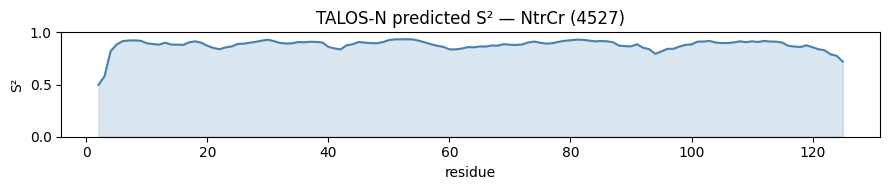

In [7]:
plt.figure(figsize=(9, 2))
plt.plot(s2['RESID'], s2['S2'], color='steelblue')
plt.fill_between(s2['RESID'], s2['S2'], alpha=0.2, color='steelblue')
plt.ylim(0, 1); plt.xlabel('residue'); plt.ylabel('S²')
plt.title('TALOS-N predicted S² — NtrCr (4527)')
plt.tight_layout()

## 5. φ/ψ torsion angles

`torsion_angles` is the parsed `pred.tab`: predicted `PHI`/`PSI` per residue plus a `CLASS` column (`Strong`/`Generous`/`Warn`/`None`/`Dyn`) flagging confidence. Plotting ψ vs φ gives a Ramachandran view of the predicted backbone.

In [8]:
pred = tn.torsion_angles
pred[['RESID', 'RESNAME', 'PHI', 'PSI', 'CLASS']].head()

,RESID,RESNAME,PHI,PSI,CLASS
0,2,M,9999.000,9999.000,None
1,3,Q,-79.700,-28.434,Dyn
2,4,R,-133.733,144.100,Warn
3,5,G,66.783,-130.115,Generous
4,6,I,-99.701,126.046,Strong


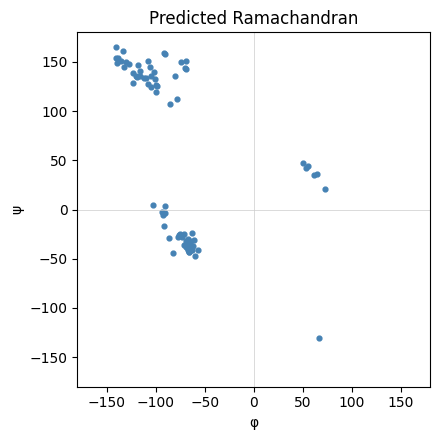

In [9]:
good = pred[pred['CLASS'].isin(['Strong', 'Generous'])]
plt.figure(figsize=(4.5, 4.5))
plt.scatter(good['PHI'], good['PSI'], s=12, color='steelblue')
plt.axhline(0, lw=0.5, color='0.8'); plt.axvline(0, lw=0.5, color='0.8')
plt.xlim(-180, 180); plt.ylim(-180, 180)
plt.xlabel('φ'); plt.ylabel('ψ'); plt.title('Predicted Ramachandran')
plt.tight_layout()

## 6. Secondary structure

`secondary_structure` is the parsed `predSS.tab` — per-residue helix / sheet / coil probabilities and a consensus call.

In [10]:
tn.secondary_structure.head()

,RESID,RESNAME,CS_CNT,CS_CNT_R2,Q_H,Q_E,Q_L,CONFIDENCE,SS_CLASS
0,2,M,8,3,0.333,0.333,0.333,0.00,L
1,3,Q,11,5,0.172,0.132,0.696,0.52,L
2,4,R,12,3,0.040,0.145,0.814,0.67,L
3,5,G,12,4,0.000,0.648,0.352,0.30,E
4,6,I,14,5,0.000,0.945,0.055,0.89,E


## 7. Starting from shifts you already have

You don't need BMRB. Build from an existing `ChemicalShifts` with `from_entry`, or hand `TalosN` a long-format DataFrame (`Comp_ID`/`Seq_ID`/`Atom_ID`/`Val`) directly and pass the sequence yourself. Pass the same `data_dir` so it finds the binary.

In [11]:
cs = ms.ChemicalShifts.from_bmrb(6586)
seq = cs.entry.sequences()['Polymer_seq_one_letter_code'].iloc[0]

# from a ChemicalShifts' entry (sequence pulled from the entry)
tn2 = talosn.TalosN.from_entry(cs.entry, data_dir=DATA_DIR)

# or straight from the shift table
tn3 = talosn.TalosN(cs.data, sequence=seq, data_dir=DATA_DIR)

s2 = tn2.predict_s2(auto_install=True)   # run-if-needed + return predS2, raising if TALOS made none
s2.head()

,RESID,RESNAME,CS_CNT,CS_CNT_R2,S2
0,1,G,10,4,0.926
1,2,A,16,6,0.927
2,3,M,16,6,0.928
3,4,G,16,4,0.922
4,5,K,16,6,0.922


## 8. The `.tab` format directly

The pieces are in `talosn.utils` if you want to drive the format yourself — write a TALOS-N input or parse any TALOS `.tab` output without going through `TalosN`.

In [12]:
path = talosn.utils.shifts_to_tab(
    talosn.utils.filter_backbone(cs.data), 'ntrc.tab', sequence=seq,
)
print(open(path).read()[:300])

# round-trips back to a DataFrame
talosn.utils.parse_tab(path).head()

DATA FIRST_RESID 1
DATA SEQUENCE GAMGKHKTFVEKYEKQIKHFGMLRRWDDSQKYLSDNVHLVCEETANYLVIWCIDLEVEEK
DATA SEQUENCE CALMEQVAHQTIVMQFILELAKSLKVDPRACFRQFFTKIKTADRQYMEGFNDELEAFKER
DATA SEQUENCE VRGRAKLRIEKAMK

VARS RESID RESNAME ATOMNAME SHIFT
FORMAT %4d %1s %4s %8.3f

   1 G C     163.272
   1 G CA     35.781


,RESID,RESNAME,ATOMNAME,SHIFT
0,1,G,C,163.272
1,1,G,CA,35.781
2,1,G,H,7.408
3,1,G,N,109.811
4,2,A,C,171.256
